<a href="https://colab.research.google.com/github/Annamalag/PI_Mineria_Datos_1-/blob/main/Notebooks/04_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Notebook 04 - Análisis de Componentes Principales (PCA)

### Objetivo

Aplicar la técnica de Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del conjunto de datos, identificar las variables que más aportan a la variabilidad de los datos y facilitar su interpretación mediante representaciones gráficas.

In [19]:
df = pd.read_csv("/content/cleaned_dataset.csv")

In [20]:
variables = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

X = df[variables]

In [21]:
X.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,99
1,37.0,1173.4,2
2,28.0,401.0,0
3,43.0,62.4,0
4,51.0,477.8,1


### Selección de variables

El PCA requiere variables numéricas continuas o discretas.

Por este motivo se utilizaron:

- Edad.
- Tiempo mensual de visualización.
- Cantidad de tickets al soporte.

Las variables categóricas (país, plan y género favorito) no fueron incluidas porque requieren un tratamiento diferente y podrían distorsionar la interpretación del PCA.

# **Escalamiento**

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [34]:
pd.DataFrame(X_scaled, columns=variables).head().round(2)

,age,monthly_watch_time_mins,customer_support_tickets
0,0.46,0.15,8.51
1,0.29,1.18,0.02
2,-0.50,-0.99,-0.16
3,0.81,-1.94,-0.16
4,1.51,-0.77,-0.07


### Escalamiento de datos

Las variables poseen diferentes unidades de medida.

Por ejemplo:

- Edad → años
- Tiempo → minutos
- Tickets → cantidad

Si no se escalan, la variable con mayor magnitud dominaría el cálculo de los componentes principales.

Por ello se utilizó StandardScaler(), que transforma todas las variables para que tengan media 0 y desviación estándar 1.

In [35]:
# Paso 4 — Ajuste de PCA sobre todas las componentes posibles
pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_

acumulada = 0

for i in range(len(varianza)):
    acumulada += varianza[i]

    print(
        "PC", i+1,
        "→", varianza[i] * 100,
        "| Acumulada →",
        acumulada * 100
    )


PC 1 → 33.65092218826913 | Acumulada → 33.65092218826913
PC 2 → 33.415246417090515 | Acumulada → 67.06616860535965
PC 3 → 32.933831394640364 | Acumulada → 100.0


La tabla de varianza explicada muestra que la primera componente principal (PC1) explica el 33,65% de la variabilidad total del conjunto de datos. La segunda componente (PC2) aporta un 33,42% adicional, alcanzando una varianza acumulada del 67,07%. Finalmente, la tercera componente (PC3) explica el 32,93% restante, completando el 100% de la varianza.

En relación con el objetivo del análisis, esto sugiere que las variables edad, tiempo de visualización mensual y cantidad de tickets de soporte aportan información diferente y complementaria, por lo que no existe una reducción importante de la dimensionalidad sin perder una parte considerable de la información. Esto es consistente con el EDA, donde se observó que las correlaciones entre estas variables eran muy bajas

In [36]:
# Paso 5 — Proyección a 2 componentes (decisión basada en varianza acumulada)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

In [38]:
# Paso 6 — Loadings: cuánto aporta cada variable original a PC1 y PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=variables,
    columns=['PC1', 'PC2']
)
print(loadings.round(3))

                            PC1    PC2
age                       0.589  0.559
monthly_watch_time_mins   0.743 -0.091
customer_support_tickets -0.318  0.824


La primera componente principal (PC1) está influenciada principalmente por el tiempo de visualización mensual (0,743), seguido por la edad (0,589). La variable cantidad de tickets de soporte tiene una contribución menor y en sentido negativo (-0,318).

análisis de los loadings muestra que las dos primeras componentes describen aspectos diferentes del comportamiento de los usuarios. La PC1 resume principalmente el nivel de consumo de la plataforma, mientras que la PC2 está relacionada con la interacción con el servicio de soporte. Esto indica que el PCA logró separar dos dimensiones distintas del conjunto de datos, aunque la varianza explicada se distribuye de manera relativamente uniforme entre las tres componentes, por lo que ninguna de ellas concentra por sí sola una parte dominante de la información.

In [24]:
pca = PCA()

componentes = pca.fit_transform(X_scaled)

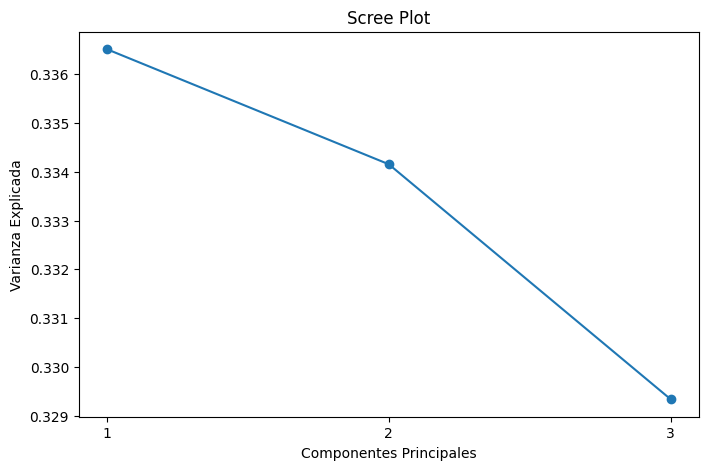

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(varianza)+1),
    varianza,
    marker="o"
)

plt.title("Scree Plot")
plt.xlabel("Componentes Principales")
plt.ylabel("Varianza Explicada")

plt.xticks(range(1, len(varianza)+1))

plt.show()

### Interpretación

El Scree Plot muestra la proporción de varianza explicada por cada componente principal.

Generalmente se conservan los componentes que explican la mayor parte de la variabilidad del conjunto de datos.

En este caso se observa que los primeros componentes concentran la mayor cantidad de información.

## **Gráfico PC1 vs PC2**

In [42]:
pca_df = pd.DataFrame(

    componentes,

    columns=["PC1","PC2","PC3"]

)

pca_df.head().round(2)

,PC1,PC2,PC3
0,-2.32,7.26,3.81
1,1.04,0.07,0.62
2,-0.98,-0.32,-0.44
3,-0.91,0.50,-1.83
4,0.34,0.86,-1.43


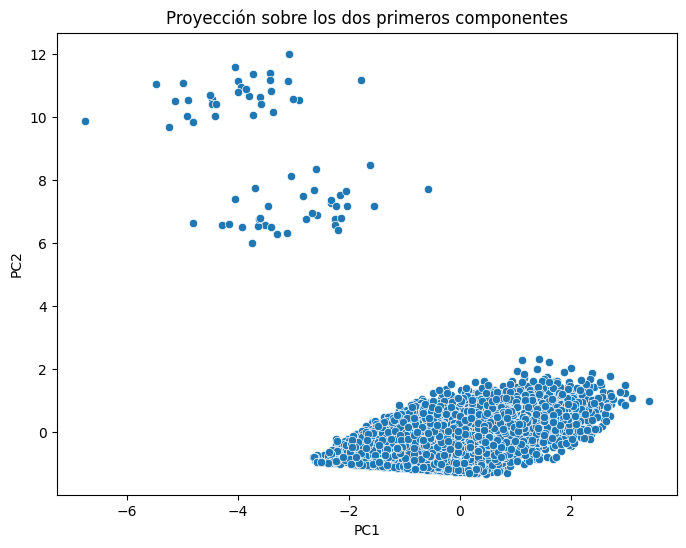

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2"

)

plt.title("Proyección sobre los dos primeros componentes")

plt.show()

### Interpretación

La representación en los dos primeros componentes principales permite visualizar la distribución de los usuarios en un espacio reducido.



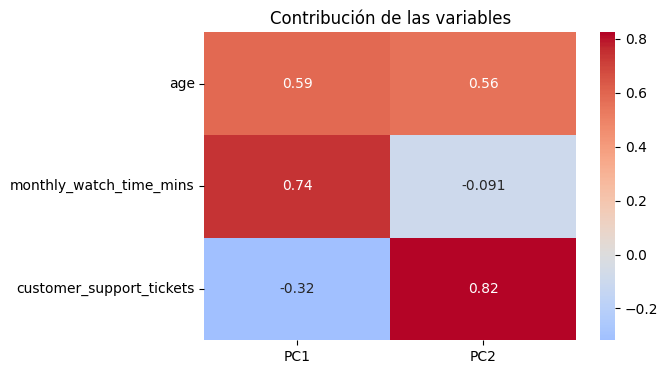

In [44]:
plt.figure(figsize=(6,4))

sns.heatmap(

    loadings,

    annot=True,

    cmap="coolwarm",

    center=0

)

plt.title("Contribución de las variables")

plt.show()

### Interpretación

Los loadings indican cuánto contribuye cada variable a cada componente principal.

Valores positivos o negativos elevados representan una mayor influencia sobre el componente correspondiente.

Esta información facilita la interpretación de qué variables explican la mayor parte de la variabilidad del conjunto de datos.

# **Conclusión del PCA**

El Análisis de Componentes Principales permitió evaluar la estructura de las variables numéricas del conjunto de datos y determinar cuánto de la información puede resumirse en un menor número de dimensiones. Las dos primeras componentes explican el 67,07% de la variabilidad total, mientras que la tercera aporta el 32,93% restante. Dado que la varianza se distribuye de manera equilibrada entre las tres componentes, no existe una reducción significativa de la dimensionalidad sin perder información relevante. Además, la ausencia de agrupamientos definidos en la proyección de las componentes principales indica que las variables numéricas consideradas no son suficientes para diferenciar claramente perfiles de usuarios. Por ello, futuros análisis podrían beneficiarse de incorporar variables categóricas, como el plan de suscripción, el país o el género favorito, mediante técnicas de codificación adecuadas, para explorar con mayor profundidad los patrones de comportamiento de los usuarios.